# Discovery

- Objetivo: Realizar una exploración inicial de los conjuntos de datos para comprender su estructura general, dimensiones, tipos de variables, calidad de los datos y distribución de la variable objetivo.

#  Importación de Librerias

In [33]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# PATHS

In [34]:
BASE_DIR = Path.cwd().parent

DATA_DIR = BASE_DIR / "data"
RAW_DIR = DATA_DIR / "raw"

# Verificación PATHS

In [35]:
print(BASE_DIR)
print(RAW_DIR)

c:\Users\sdecicco\OneDrive - loteriadelaciudad.gob.ar\Escritorio\Diplomatura en IA\TP2
c:\Users\sdecicco\OneDrive - loteriadelaciudad.gob.ar\Escritorio\Diplomatura en IA\TP2\data\raw


# Carga y lectura dataset

In [36]:
train = pd.read_csv(RAW_DIR / "smoking_prediction.xlsx - smoking_prediction.csv")

train.head(10)

,ID,gender,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),...,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,oral,dental caries,tartar,smoking
0,0,F,40,155,60,3.38,0.04,0.04,0.04,0.04,...,0.51,0.04,0.00,0.75,0.79,1.13,Y,0,Y,0
1,1,F,40,160,60,3.38,0.01,0.00,0.04,0.04,...,0.50,0.04,0.00,0.92,0.79,0.75,Y,0,Y,0
2,2,M,55,170,60,3.33,0.01,0.01,0.04,0.04,...,0.63,0.04,0.04,0.88,0.67,0.92,Y,0,N,1
3,3,M,40,165,70,3.67,0.05,0.05,0.04,0.04,...,0.59,0.04,0.04,0.79,1.08,0.75,Y,0,Y,0
4,4,F,40,155,60,3.58,0.04,0.04,0.04,0.04,...,0.50,0.04,0.00,0.67,0.58,0.92,Y,0,N,0
5,5,M,30,180,75,3.54,0.04,0.04,0.04,0.04,...,0.67,0.04,0.04,0.75,1.13,1.38,Y,0,Y,0
6,6,M,40,160,60,3.55,0.04,0.04,0.04,0.04,...,0.71,0.04,0.00,0.88,1.13,1.63,Y,1,Y,1
7,7,M,45,165,90,4.00,0.04,0.04,0.04,0.04,...,0.63,0.04,0.04,1.58,2.96,4.63,Y,0,Y,0
8,9,F,50,150,60,3.54,0.00,0.01,0.04,0.04,...,0.55,0.04,0.01,1.29,1.29,0.58,Y,0,N,0
9,10,M,45,175,75,3.71,0.04,0.04,0.04,0.04,...,0.67,0.04,0.01,1.08,1.00,2.63,Y,0,N,0


# Tamaño del DataSet

In [37]:
train.shape

(50000, 27)

# Descriptiva

In [38]:
train.describe()

,ID,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),systolic,...,HDL,LDL,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,dental caries,smoking
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,...,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,26284.994580,44.189300,164.652000,65.878700,3.415468,0.027999,0.027865,0.041026,0.041048,5.063196,...,2.388346,4.791527,0.594483,0.043708,0.018538,1.094032,1.130193,1.668978,0.213120,0.366580
std,16015.070567,12.090086,9.208778,12.831355,0.386760,0.024137,0.024297,0.006325,0.006389,0.570171,...,0.615541,1.709246,0.066414,0.017509,0.017504,0.828010,1.327440,2.110348,0.409516,0.481875
min,0.000000,20.000000,130.000000,30.000000,2.130000,0.000000,0.000000,0.040000,0.040000,2.960000,...,0.170000,0.040000,0.170000,0.040000,0.000000,0.250000,0.040000,0.040000,0.000000,0.000000
25%,12499.750000,40.000000,160.000000,55.000000,3.170000,0.010000,0.010000,0.040000,0.040000,4.670000,...,1.960000,3.830000,0.550000,0.040000,0.010000,0.790000,0.630000,0.710000,0.000000,0.000000
50%,24999.500000,40.000000,165.000000,65.000000,3.420000,0.040000,0.040000,0.040000,0.040000,5.000000,...,2.290000,4.710000,0.590000,0.040000,0.010000,0.960000,0.880000,1.040000,0.000000,0.000000
75%,40034.250000,55.000000,170.000000,75.000000,3.670000,0.040000,0.040000,0.040000,0.040000,5.420000,...,2.750000,5.670000,0.630000,0.040000,0.040000,1.210000,1.290000,1.830000,0.000000,1.000000
max,55690.000000,85.000000,190.000000,135.000000,5.380000,0.380000,0.380000,0.080000,0.080000,10.000000,...,25.750000,77.500000,0.880000,0.250000,0.460000,54.630000,121.420000,41.630000,1.000000,1.000000


# A partir del análisis descriptivo se observa que varias variables presentan diferencias entre media y mediana, sugiriendo distribuciones asimétricas. Asimismo, variables como Gtp, ALT y AST presentan máximos considerablemente superiores a sus percentiles superiores, lo que podría indicar la presencia de valores extremos u outliers. Por otro lado, variables como edad, peso y altura presentan rangos consistentes con los esperados para la población analizada. Estas observaciones serán profundizadas mediante histogramas y boxplots durante la etapa de EDA.

# Estructura del DataSet

In [39]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 27 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   50000 non-null  int64  
 1   gender               50000 non-null  object 
 2   age                  50000 non-null  int64  
 3   height(cm)           50000 non-null  int64  
 4   weight(kg)           50000 non-null  int64  
 5   waist(cm)            50000 non-null  float64
 6   eyesight(left)       50000 non-null  float64
 7   eyesight(right)      50000 non-null  float64
 8   hearing(left)        50000 non-null  float64
 9   hearing(right)       50000 non-null  float64
 10  systolic             50000 non-null  float64
 11  relaxation           50000 non-null  float64
 12  fasting blood sugar  50000 non-null  float64
 13  Cholesterol          50000 non-null  float64
 14  triglyceride         50000 non-null  float64
 15  HDL                  50000 non-null 

# Distribución Fumador - No Fumador

In [40]:
train["smoking"].value_counts()

smoking
0    31671
1    18329
Name: count, dtype: int64

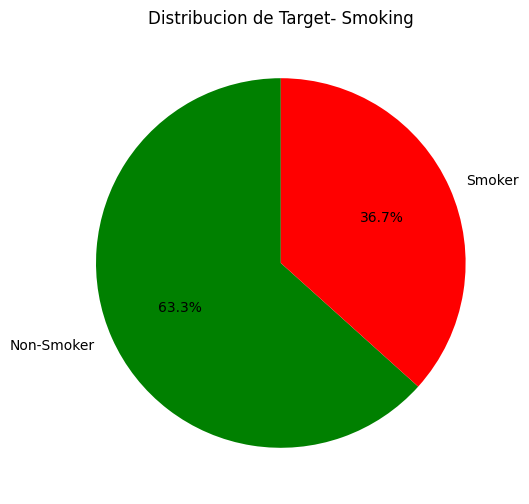

In [41]:
plt.figure(figsize=(6,6))
conteo = train["smoking"].value_counts()
labels = ["Non-Smoker", "Smoker"]
plt.pie(conteo, labels=labels, autopct="%1.1f%%", startangle=90, colors=["green","red"])
plt.title("Distribucion de Target- Smoking")
plt.show()

In [42]:
train.duplicated().sum()

np.int64(0)

In [43]:
train.isnull().sum()

ID                     0
gender                 0
age                    0
height(cm)             0
weight(kg)             0
waist(cm)              0
eyesight(left)         0
eyesight(right)        0
hearing(left)          0
hearing(right)         0
systolic               0
relaxation             0
fasting blood sugar    0
Cholesterol            0
triglyceride           0
HDL                    0
LDL                    0
hemoglobin             0
Urine protein          0
serum creatinine       0
AST                    0
ALT                    0
Gtp                    0
oral                   0
dental caries          0
tartar                 0
smoking                0
dtype: int64

# Visualización rápida de distribuciones

array([[<Axes: title={'center': 'ID'}>, <Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'height(cm)'}>,
        <Axes: title={'center': 'weight(kg)'}>,
        <Axes: title={'center': 'waist(cm)'}>],
       [<Axes: title={'center': 'eyesight(left)'}>,
        <Axes: title={'center': 'eyesight(right)'}>,
        <Axes: title={'center': 'hearing(left)'}>,
        <Axes: title={'center': 'hearing(right)'}>,
        <Axes: title={'center': 'systolic'}>],
       [<Axes: title={'center': 'relaxation'}>,
        <Axes: title={'center': 'fasting blood sugar'}>,
        <Axes: title={'center': 'Cholesterol'}>,
        <Axes: title={'center': 'triglyceride'}>,
        <Axes: title={'center': 'HDL'}>],
       [<Axes: title={'center': 'LDL'}>,
        <Axes: title={'center': 'hemoglobin'}>,
        <Axes: title={'center': 'Urine protein'}>,
        <Axes: title={'center': 'serum creatinine'}>,
        <Axes: title={'center': 'AST'}>],
       [<Axes: title={'center': 'ALT'}>, <Axes

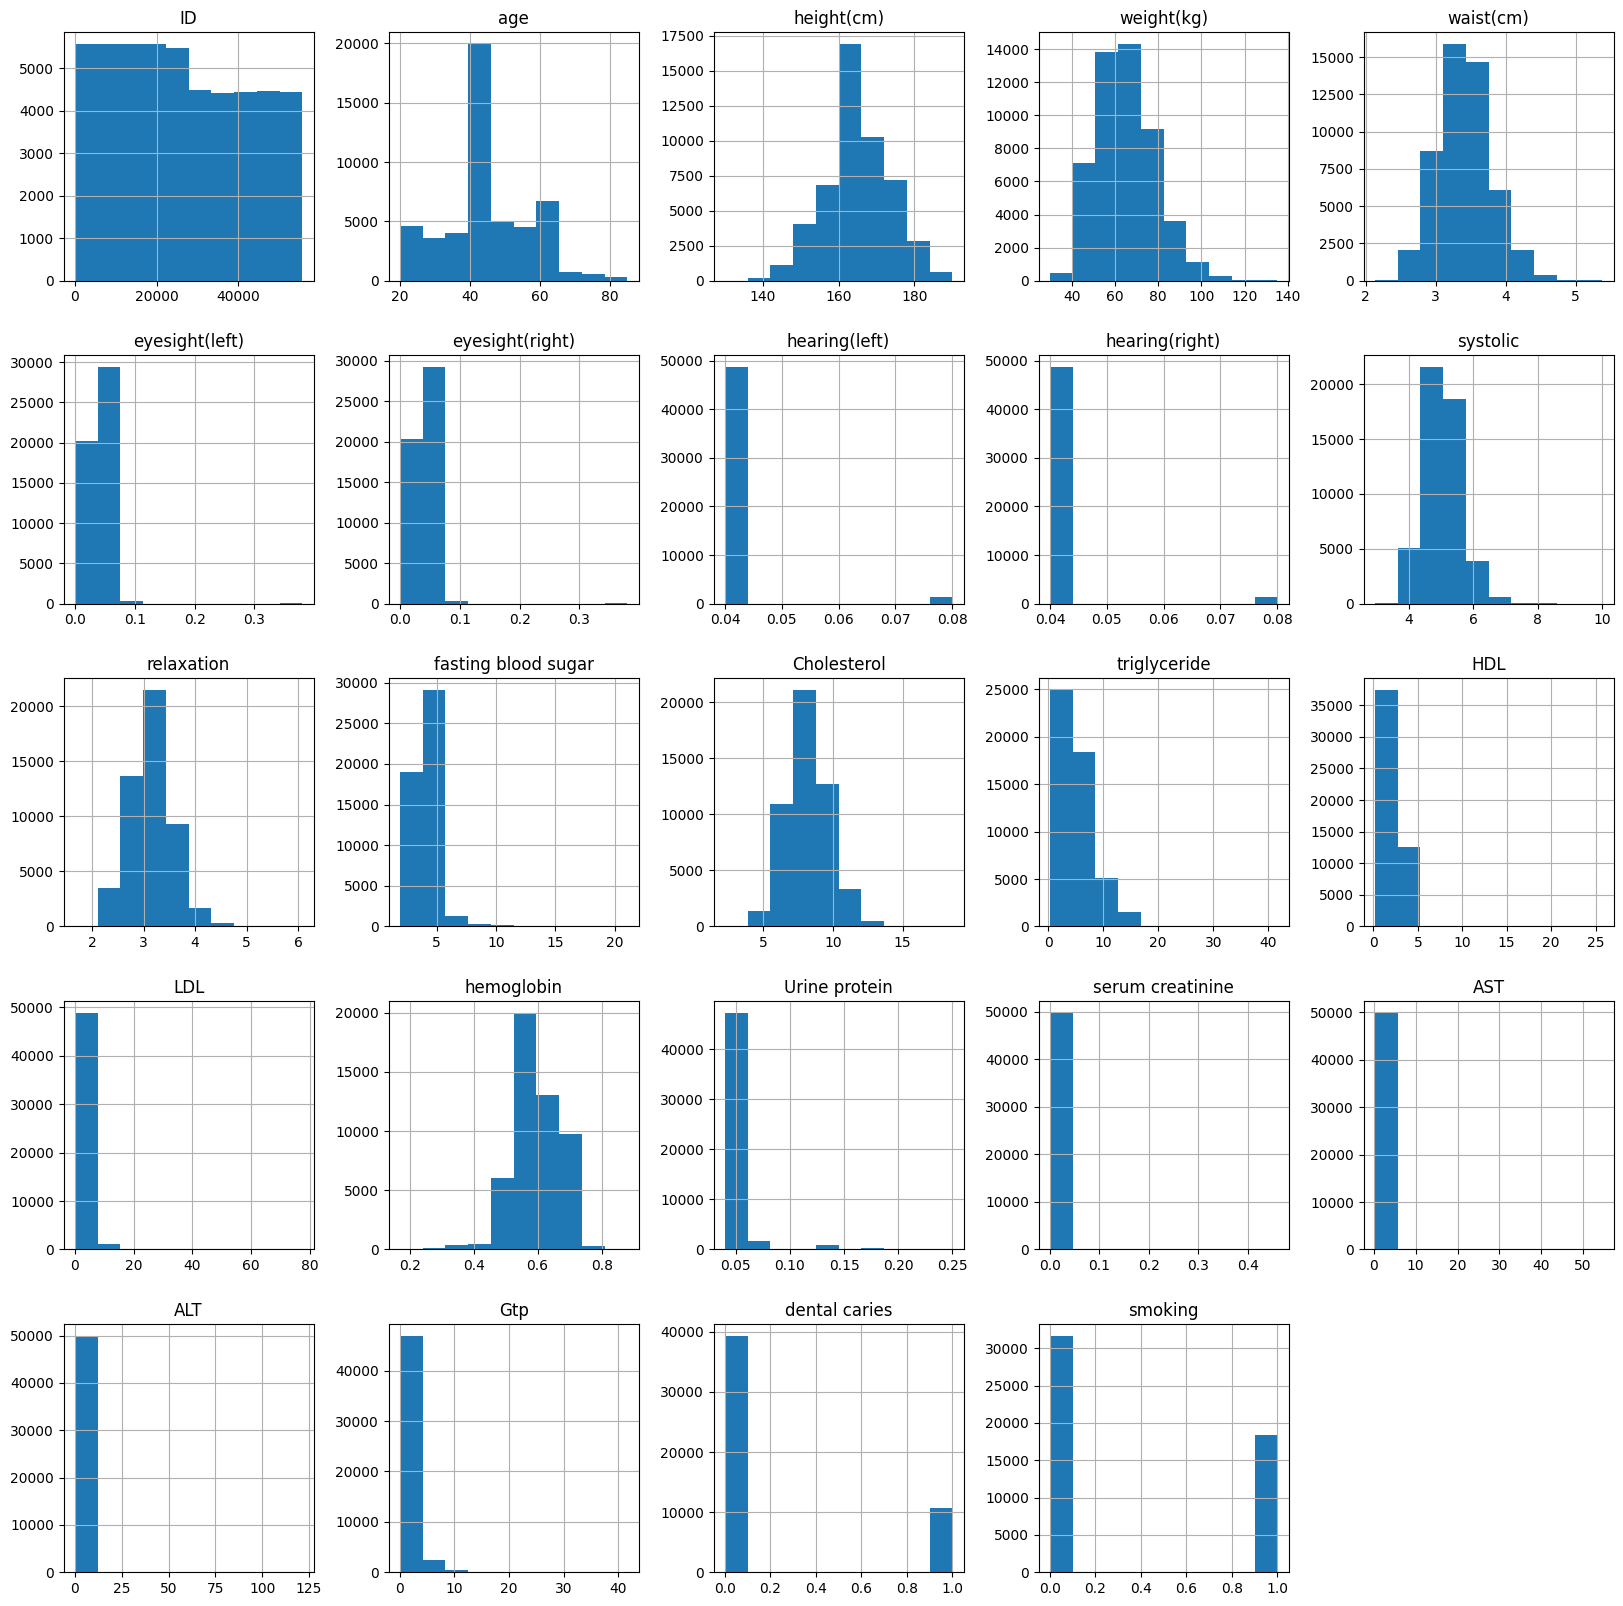

In [44]:
train.hist(figsize=(20,20))

# Observaciones Discovery

- No se detectan observaciones incompletas
- No se detectan duplicados
- oral presenta un único valor → candidata a eliminar
- gender es binaria
- tartar es binaria y balanceada
- Existen variables con fuerte asimetría
- Existen variables aparentemente discretizadas

# Variables categoricas

In [45]:
train.select_dtypes(include='object').columns

Index(['gender', 'oral', 'tartar'], dtype='object')

In [46]:
train["gender"].value_counts()

gender
M    31784
F    18216
Name: count, dtype: int64

In [47]:
train["oral"].value_counts()

oral
Y    50000
Name: count, dtype: int64

In [48]:
train["tartar"].value_counts()

tartar
Y    27789
N    22211
Name: count, dtype: int64

- oral presenta varianza cero -> candidata a eliminación
- ID parece no aportar información (PK) -> Eliminación
- Existen variables con correlaciones moderadas respecto a smoking
- Se detectan distribuciones asimétricas
- No se observan datos faltantes ni duplicados

# Correlación

In [49]:
train.corr(numeric_only=True)["smoking"].sort_values()

HDL                   -0.177006
age                   -0.163722
LDL                   -0.045708
Cholesterol           -0.030015
hearing(left)         -0.021871
hearing(right)        -0.017727
ID                     0.012211
Urine protein          0.015423
AST                    0.057354
eyesight(left)         0.070211
eyesight(right)        0.073018
systolic               0.073198
ALT                    0.094129
fasting blood sugar    0.098112
dental caries          0.103757
relaxation             0.108101
waist(cm)              0.224611
serum creatinine       0.224815
Gtp                    0.235969
triglyceride           0.251112
weight(kg)             0.301405
height(cm)             0.396284
hemoglobin             0.397073
smoking                1.000000
Name: smoking, dtype: float64

# Interpretación general del coeficiente de correlación

Como referencia para el análisis exploratorio, se consideró la siguiente clasificación orientativa de la magnitud de la correlación:

| Valor absoluto de correlación (|corr|) | Interpretación |
|-----------------------------------------|----------------|
| < 0.10 | Muy débil |
| 0.10 - 0.30 | Débil |
| 0.30 - 0.50 | Moderada |
| > 0.50 | Fuerte |

- Nota: Los rangos utilizados constituyen una referencia orientativa para el análisis exploratorio y no representan criterios absolutos de selección de variables.

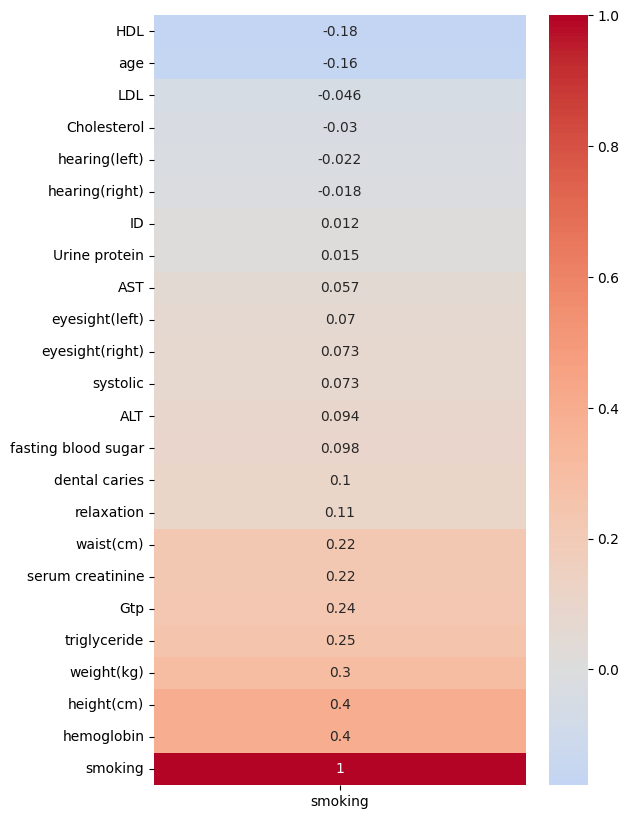

In [50]:
corr_smoking = (
    train.corr(numeric_only=True)[["smoking"]]
    .sort_values("smoking")
)

plt.figure(figsize=(6,10))

sns.heatmap(
    corr_smoking,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.show()

# Las variables con mayor correlación positiva respecto al target smoking son:

- hemoglobin
- height
- weight
- triglyceride
- Gtp
- waist

# Por lo tanto parecen contener información útil y merecen atención durante el EDA

- HDL = -0.18

- a mayor HDL, menor tendencia a smoking

### Nota sobre el uso de la matriz de correlación. Fecha: 24/06/2026.-

Durante el desarrollo de este trabajo se dedicó especial atención a comprender conceptos como las distribuciones de las variables y las relaciones existentes entre ellas dentro del conjunto de datos. Como parte de ese proceso de aprendizaje y exploración, se incorporó una matriz de correlación para complementar el análisis visual realizado durante las etapas de Discovery y EDA.

Posteriormente, a partir de las observaciones realizadas durante las clases y nuevamente durante las defensas, se recordó que el uso de correlación no constituye la herramienta más adecuada cuando la variable objetivo corresponde a un problema de clasificación binaria como el presente.

Se decidió igualmente conservar este análisis dentro del trabajo como parte del recorrido realizado durante el TP2 y del proceso de aprendizaje asociado a la comprensión de los datos y de las técnicas de análisis exploratorio.

Asimismo, y en línea con las recomendaciones realizadas durante la cursada respecto del uso de herramientas de Inteligencia Artificial, se reconoce que en algunos momentos se recurrió a este tipo de apoyo con el objetivo de acelerar la comprensión de conceptos, flujo de trabajo y sentar bases sobre temas que resultaban particularmente complejos para un perfil sin experiencia previa en programación ni análisis de datos, procurando siempre priorizar el entendimiento, la validación y el aprendizaje por encima de la mera obtención de resultados.

La intención detrás de este enfoque nunca fue reemplazar el aprendizaje sino, por el contrario, profundizarlo, dedicarle tiempo y esfuerzo a conceptos que inicialmente resultaban difíciles y construir gradualmente una base de trabajo que permita seguir creciendo y practicando de manera autónoma en el futuro.

Finalmente, se destaca que la información obtenida a partir de la matriz de correlación no fue utilizada para seleccionar variables, eliminar atributos ni tomar decisiones posteriores dentro del pipeline de Machine Learning implementado, por lo que las etapas de preprocesamiento, entrenamiento, validación y generación de predicciones no se vieron afectadas por este análisis exploratorio.





In [65]:
for col in train.columns:
    print(col, train[col].nunique())

ID 50000
gender 2
age 14
height(cm) 13
weight(kg) 22
waist(cm) 111
eyesight(left) 6
eyesight(right) 6
hearing(left) 2
hearing(right) 2
systolic 130
relaxation 95
fasting blood sugar 276
Cholesterol 286
triglyceride 390
HDL 126
LDL 289
hemoglobin 27
Urine protein 6
serum creatinine 14
AST 219
ALT 245
Gtp 488
oral 1
dental caries 2
tartar 2
smoking 2


# Variable target

- smoking	

# Variables categoricas binarias

- gender	
- dental caries	
- tartar

# Variable identificador

- ID

# Variables continuas

- waist(cm)
- systolic
- relaxation
- fasting blood sugar
- cholesterol
- triglyceride
- HDL
- LDL
- hemoglobin
- serum creatinine
- AST
- ALT
- Gtp

# Variables discretas

- age
- height(cm)
- weight(kg)

# Variables constantes

- oral

# Variables discretizadas ordinales

- Urine protein	
- eyesight(left)	
- eyesight(right)
- hearing(left)	
- hearing(right)

In [52]:
train.drop(columns=['ID']).duplicated().sum()

np.int64(5448)

# Se detectaron 5448 registros duplicados al excluir la columna ID. Debido a que el DataSet contiene múltiples variables discretas y categóricas, estos registros podrían corresponder tanto a observaciones repetidas como a individuos distintos con características idénticas. Se requiere una revisión adicional antes de decidir su eliminación.

In [53]:
train.drop(columns=['ID']).duplicated(keep=False).sum()

np.int64(10896)

# 5448 pares de registros repetidos. 10896 / 2 = 5448.- Hay una cantidad importante de observaciones que aparecen exactamente dos veces.

In [54]:
train[train.drop(columns=['ID']).duplicated(keep=False)]

,ID,gender,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),...,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,oral,dental caries,tartar,smoking
3,3,M,40,165,70,3.67,0.05,0.05,0.04,0.04,...,0.59,0.04,0.04,0.79,1.08,0.75,Y,0,Y,0
7,7,M,45,165,90,4.00,0.04,0.04,0.04,0.04,...,0.63,0.04,0.04,1.58,2.96,4.63,Y,0,Y,0
15,16,F,40,170,55,2.83,0.04,0.04,0.04,0.04,...,0.54,0.04,0.01,0.63,0.42,0.67,Y,0,N,0
17,19,M,35,165,70,3.63,0.04,0.01,0.04,0.04,...,0.67,0.04,0.01,1.54,1.79,1.25,Y,0,Y,1
21,26,M,40,180,85,3.42,0.05,0.05,0.04,0.04,...,0.67,0.04,0.01,1.75,2.71,1.54,Y,0,N,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,27343,M,50,160,55,2.96,0.00,0.01,0.04,0.04,...,0.55,0.04,0.04,0.96,0.58,0.92,Y,0,Y,1
49996,27350,M,30,170,70,3.33,0.05,0.04,0.04,0.04,...,0.63,0.04,0.01,1.08,1.21,0.75,Y,1,Y,1
49997,27351,M,20,165,65,3.54,0.05,0.05,0.04,0.04,...,0.67,0.04,0.01,1.46,1.46,2.92,Y,0,Y,1
49998,27352,F,60,160,45,2.96,0.00,0.00,0.04,0.04,...,0.58,0.04,0.00,0.79,0.67,1.04,Y,1,Y,0


# 10896 filas participan en grupos duplicados. 21.8% del dataset.

In [55]:
dup = train[train.drop(columns=['ID']).duplicated(keep=False)]

dup.sort_values(
    by=list(train.columns[1:])
).head(20)

,ID,gender,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),...,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,oral,dental caries,tartar,smoking
710,887,F,25,155,50,2.67,0.04,0.04,0.04,0.04,...,0.54,0.04,0.00,0.50,0.38,0.42,Y,0,Y,0
47037,12322,F,25,155,50,2.67,0.04,0.04,0.04,0.04,...,0.54,0.04,0.00,0.50,0.38,0.42,Y,0,Y,0
8223,10328,F,40,140,40,2.46,0.01,0.01,0.04,0.04,...,0.59,0.04,0.00,0.75,0.67,0.96,Y,0,Y,0
46712,10636,F,40,140,40,2.46,0.01,0.01,0.04,0.04,...,0.59,0.04,0.00,0.75,0.67,0.96,Y,0,Y,0
41102,51389,F,40,140,55,3.38,0.00,0.00,0.04,0.04,...,0.59,0.04,0.00,1.38,1.88,4.92,Y,0,N,0
46463,9374,F,40,140,55,3.38,0.00,0.00,0.04,0.04,...,0.59,0.04,0.00,1.38,1.88,4.92,Y,0,N,0
35409,44247,F,40,145,40,2.50,0.00,0.00,0.04,0.04,...,0.54,0.04,0.00,0.83,0.42,0.42,Y,0,N,0
46735,10767,F,40,145,40,2.50,0.00,0.00,0.04,0.04,...,0.54,0.04,0.00,0.83,0.42,0.42,Y,0,N,0
16373,20410,F,40,145,40,2.58,0.04,0.04,0.04,0.04,...,0.54,0.04,0.00,1.33,0.83,2.04,Y,0,N,0
44668,566,F,40,145,40,2.58,0.04,0.04,0.04,0.04,...,0.54,0.04,0.00,1.33,0.83,2.04,Y,0,N,0


# Al analizar los registros duplicados excluyendo la columna ID, se detectaron 5448 observaciones repetidas. La inspección manual mostró múltiples casos donde todas las variables coinciden exactamente, diferenciándose únicamente por el identificador. Esto sugiere la presencia de registros duplicados dentro del conjunto de entrenamiento.

In [56]:
dup = train[train.drop(columns=['ID']).duplicated(keep=False)]

dup['gender'].value_counts(normalize=True)

gender
M    0.630507
F    0.369493
Name: proportion, dtype: float64

In [57]:
train['gender'].value_counts(normalize=True)

gender
M    0.63568
F    0.36432
Name: proportion, dtype: float64

# Se detectaron 5448 registros duplicados (10896 observaciones involucradas). La distribución por género en los registros duplicados es prácticamente idéntica a la del conjunto completo, por lo que no se observa un sesgo evidente asociado a esta variable.

In [58]:
dup['gender'].value_counts()

gender
M    6870
F    4026
Name: count, dtype: int64

In [59]:
dup['smoking'].value_counts()

smoking
0    6942
1    3954
Name: count, dtype: int64

### Análisis de registros duplicados

- Se realizó una revisión de registros duplicados excluyendo la columna `ID`, ya que esta funciona como identificador único y no aporta información para el modelado.

- Se detectaron `5448 registros duplicados`, involucrando un total de `10896 observaciones`. Al inspeccionar una muestra de estos casos, se observó que todas las variables presentan exactamente los mismos valores y únicamente difieren en el identificador.

- Adicionalmente, se comparó la distribución de las variables `gender` y `smoking` entre el conjunto completo y el subconjunto de registros duplicados. Las proporciones resultaron prácticamente idénticas, por lo que no se observan sesgos evidentes asociados a estas variables.

- Debido a que aún no se determinó si estos registros corresponden a errores de duplicación o a observaciones válidas con características idénticas, se decidió documentar el hallazgo y postergar cualquier decisión de eliminación para la etapa de preparación de datos y feature engineering.


# Check dataset de test

In [60]:
test = pd.read_csv(RAW_DIR / "smoking_prediction_entrega.xlsx - smoking_prediction.csv")

test.head(20)

,ID,gender,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),...,LDL,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,oral,dental caries,tartar
0,27358,M,25,160,65,3.42,0.05,0.00,0.04,0.04,...,3.04,0.63,0.04,0.01,0.75,0.71,0.71,Y,0,Y
1,27364,M,30,180,80,3.46,0.04,0.01,0.04,0.04,...,4.21,0.59,0.04,0.04,0.79,1.13,1.33,Y,0,N
2,27368,M,55,165,60,3.42,0.00,0.01,0.04,0.04,...,2.04,0.63,0.04,0.01,1.08,1.29,2.00,Y,1,Y
3,27378,M,20,175,75,3.63,0.05,0.05,0.04,0.04,...,3.71,0.63,0.04,0.04,0.83,0.58,0.46,Y,0,N
4,27381,M,25,165,80,3.79,0.04,0.04,0.04,0.04,...,6.63,0.67,0.04,0.04,1.25,1.63,1.96,Y,1,Y
5,27386,M,45,175,65,3.33,0.05,0.05,0.04,0.04,...,4.63,0.71,0.04,0.04,0.71,0.50,0.79,Y,0,N
6,27388,M,55,160,65,3.50,0.04,0.05,0.04,0.04,...,3.38,0.54,0.04,0.04,1.54,1.79,1.96,Y,0,Y
7,27393,F,50,150,55,3.08,0.05,0.05,0.04,0.04,...,4.00,0.50,0.04,0.00,0.79,0.54,0.67,Y,0,N
8,27406,F,45,160,70,3.71,0.04,0.01,0.04,0.04,...,6.04,0.58,0.04,0.00,1.00,0.71,0.92,Y,0,Y
9,27417,M,40,180,90,3.67,0.04,0.04,0.04,0.04,...,5.08,0.67,0.04,0.04,1.50,1.88,1.75,Y,0,Y


In [61]:
test.shape

(5692, 26)

In [62]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5692 entries, 0 to 5691
Data columns (total 26 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   5692 non-null   int64  
 1   gender               5692 non-null   object 
 2   age                  5692 non-null   int64  
 3   height(cm)           5692 non-null   int64  
 4   weight(kg)           5692 non-null   int64  
 5   waist(cm)            5692 non-null   float64
 6   eyesight(left)       5692 non-null   float64
 7   eyesight(right)      5692 non-null   float64
 8   hearing(left)        5692 non-null   float64
 9   hearing(right)       5692 non-null   float64
 10  systolic             5692 non-null   float64
 11  relaxation           5692 non-null   float64
 12  fasting blood sugar  5692 non-null   float64
 13  Cholesterol          5692 non-null   float64
 14  triglyceride         5692 non-null   float64
 15  HDL                  5692 non-null   f

In [63]:
test.isnull().sum().sum()

np.int64(0)

In [64]:
set(train.columns) - set(test.columns)

{'smoking'}

### Validación del conjunto de test

Se realizó una validación básica del conjunto de datos de prueba `test` para verificar su consistencia respecto del conjunto de entrenamiento `train`.

Las verificaciones realizadas incluyeron:

* Revisión de dimensiones `shape`.
* Revisión de tipos de datos `info()`.
* Búsqueda de valores nulos.
* Comparación de columnas entre ambos conjuntos.

Los resultados muestran que el conjunto de prueba presenta la misma estructura y tipos de datos que el conjunto de entrenamiento. No se detectaron valores nulos y la única diferencia observada corresponde a la ausencia de la variable objetivo `smoking`, situación esperada dado que el objetivo del conjunto de prueba es generar las predicciones finales del modelo.
